# `tet_effect.py`

Tái tạo chart hiệu ứng Tết + xuất bảng ngày Tết dương lịch 2012-2024 (`tet_dates.csv`, `tet_yearly_stats.csv`) dùng cho feature `days_from_tet` ở Giai đoạn 6. Notebook chạy đúng code gốc, chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Downloads/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase1_descriptive/tet_effect.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
# Hiệu ứng Tết — tái tạo chart trong đề bài + xuất bảng ngày Tết cho Phần B
# Output:
#   EDA_Insight/phase1_descriptive/data/tet_dates.csv  — mồng 1 Tết dương lịch 2012–2024 (dùng làm feature)
#   EDA_Insight/output/phase1/tet_effect.png — chart Revenue/COGS quanh Tết
# Chạy: python EDA_Insight/phase1_descriptive/tet_effect.py (sau khi activate .venv)

import pandas as pd
import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt
from lunardate import LunarDate
from pathlib import Path

HERE = Path(__file__).resolve().parent           # EDA_Insight/phase1_descriptive/
DATA = HERE.parent.parent / "data"                # dữ liệu gốc: <project root>/data
EXPORT = HERE / "data"                            # data trung gian riêng của Phase 1
EXPORT.mkdir(exist_ok=True)
OUT = HERE.parent / "output" / "phase1"           # chart: EDA_Insight/output/phase1/
OUT.mkdir(parents=True, exist_ok=True)

## 1. BẢNG NGÀY TẾT (mồng 1 âm lịch -> dương lịch)

In [3]:
tet_rows = []
for year in range(2012, 2025):
    solar = LunarDate(year, 1, 1).toSolarDate()
    tet_rows.append({"year": year, "tet_date": pd.Timestamp(solar)})
tet = pd.DataFrame(tet_rows)
tet.to_csv(EXPORT / "tet_dates.csv", index=False)
print("Mồng 1 Tết từng năm:")
for _, r in tet.iterrows():
    print(f"  {r['year']}: {r['tet_date'].date()}")

Mồng 1 Tết từng năm:
  2012: 2012-01-23
  2013: 2013-02-10
  2014: 2014-01-31
  2015: 2015-02-19
  2016: 2016-02-08
  2017: 2017-01-28
  2018: 2018-02-16
  2019: 2019-02-05
  2020: 2020-01-25
  2021: 2021-02-12
  2022: 2022-02-01
  2023: 2023-01-22
  2024: 2024-02-10


/var/folders/t9/tstf90y13wd9p_7gc7pf9htr0000gp/T/ipykernel_73341/1797479759.py:3: DeprecationWarning: toSolarDate is deprecated, use to_solar_date instead
  solar = LunarDate(year, 1, 1).toSolarDate()


## 2. GẮN OFFSET "CÁCH TẾT BAO NHIÊU NGÀY" CHO MỖI NGÀY BÁN HÀNG

In [4]:
sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])

WINDOW = 30
frames = []
for tet_date in tet["tet_date"]:
    lo, hi = tet_date - pd.Timedelta(days=WINDOW), tet_date + pd.Timedelta(days=WINDOW)
    w = sales[(sales["Date"] >= lo) & (sales["Date"] <= hi)].copy()
    if len(w) == 0:
        continue
    w["offset"] = (w["Date"] - tet_date).dt.days
    frames.append(w)
around_tet = pd.concat(frames)
print(f"\nSố cái Tết nằm trong dữ liệu: {around_tet['Date'].dt.year.nunique()} "
      f"({len(around_tet)} ngày quan sát)")

avg = around_tet.groupby("offset")[["Revenue", "COGS"]].mean() / 1e6


Số cái Tết nằm trong dữ liệu: 10 (619 ngày quan sát)


## 3. THỐNG KÊ ĐỊNH LƯỢNG

In [5]:
def band_mean(lo, hi, col="Revenue"):
    return avg.loc[lo:hi, col].mean()

baseline_year = sales["Revenue"].mean() / 1e6
print(f"\nRevenue trung bình cả năm      : {baseline_year:.2f} triệu/ngày")
print(f"Vùng đáy trước Tết (-30..-15)  : {band_mean(-30, -15):.2f} triệu/ngày")
print(f"Tuần trước Tết (-7..-1)        : {band_mean(-7, -1):.2f} triệu/ngày")
print(f"Mồng 1 ±3 ngày (-3..+3)        : {band_mean(-3, 3):.2f} triệu/ngày")
print(f"Tuần sau Tết (+1..+7)          : {band_mean(1, 7):.2f} triệu/ngày")
print(f"Hồi phục (+15..+30)            : {band_mean(15, 30):.2f} triệu/ngày")
ratio = (around_tet["COGS"] / around_tet["Revenue"]).groupby(around_tet["offset"]).mean()
print(f"Tỷ lệ COGS/Revenue quanh Tết   : min {ratio.min():.3f} — max {ratio.max():.3f}")


Revenue trung bình cả năm      : 4.29 triệu/ngày
Vùng đáy trước Tết (-30..-15)  : 2.60 triệu/ngày
Tuần trước Tết (-7..-1)        : 2.94 triệu/ngày
Mồng 1 ±3 ngày (-3..+3)        : 3.30 triệu/ngày
Tuần sau Tết (+1..+7)          : 3.34 triệu/ngày
Hồi phục (+15..+30)            : 3.83 triệu/ngày
Tỷ lệ COGS/Revenue quanh Tết   : min 0.793 — max 0.875


## 4. VẼ CHART GIỐNG ẢNH TRONG ĐỀ


Đã lưu chart: /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/output/phase1/tet_effect.png


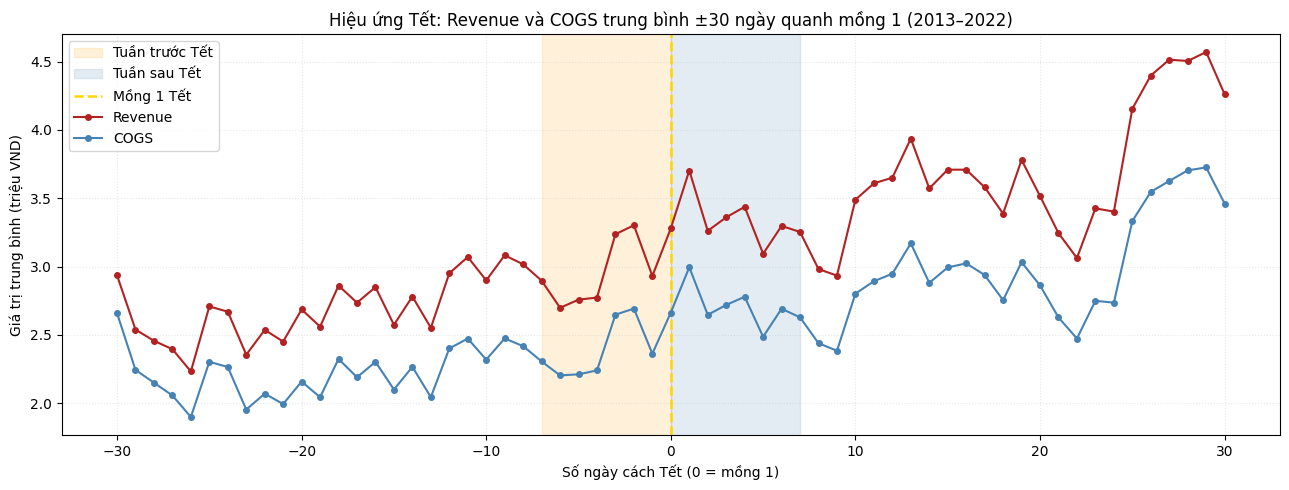

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axvspan(-7, 0, color="orange", alpha=0.15, label="Tuần trước Tết")
ax.axvspan(0, 7, color="steelblue", alpha=0.15, label="Tuần sau Tết")
ax.axvline(0, color="gold", linestyle="--", linewidth=1.8, label="Mồng 1 Tết")
ax.plot(avg.index, avg["Revenue"], "o-", color="firebrick", markersize=4,
        linewidth=1.5, label="Revenue")
ax.plot(avg.index, avg["COGS"], "o-", color="steelblue", markersize=4,
        linewidth=1.5, label="COGS")
ax.set_xlabel("Số ngày cách Tết (0 = mồng 1)")
ax.set_ylabel("Giá trị trung bình (triệu VND)")
ax.set_title("Hiệu ứng Tết: Revenue và COGS trung bình ±30 ngày quanh mồng 1 (2013–2022)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3, linestyle=":")
fig.tight_layout()
out = OUT / "tet_effect.png"
fig.savefig(out, dpi=150)
print(f"\nĐã lưu chart: {out}")

## 5. ĐỊNH LƯỢNG THEO TỪNG NĂM — Giai đoạn 1 (Descriptive) mở rộng Mỗi năm có baseline riêng (Revenue TB ngày của chính năm đó), tránh bị lệch do 2013-2015 và 2019-2022 có mức doanh thu nền khác hẳn nhau (xem structural break 2019 trong EDA_khoi_dong.ipynb / descriptive_summary.md).

In [7]:
print("\n" + "=" * 70)
print("5. ĐỊNH LƯỢNG HIỆU ỨNG TẾT THEO TỪNG NĂM (baseline = riêng năm đó)")
print("=" * 70)

rows = []
for _, trow in tet.iterrows():
    year, tdate = int(trow["year"]), trow["tet_date"]
    if year < 2013 or year > 2022:
        continue  # ngoài phạm vi sales.csv (2012-07-04 .. 2022-12-31)

    year_sales = sales[sales["Date"].dt.year == year]
    if len(year_sales) == 0:
        continue
    baseline = year_sales["Revenue"].mean() / 1e6

    w = sales[(sales["Date"] >= tdate - pd.Timedelta(days=30)) &
              (sales["Date"] <= tdate + pd.Timedelta(days=30))].copy()
    w["offset"] = (w["Date"] - tdate).dt.days
    g = w.set_index("offset")["Revenue"] / 1e6

    def pct(lo, hi):
        band = g.loc[lo:hi]
        if len(band) == 0 or baseline == 0:
            return float("nan")
        return (band.mean() / baseline - 1) * 100

    rows.append({
        "year": year,
        "tet_date": tdate.date().isoformat(),
        "baseline_trieu_ngay": round(baseline, 2),
        "pre_week_pct": round(pct(-7, -1), 1),      # tuần trước Tết vs baseline
        "dip_pct": round(pct(-3, 3), 1),            # quanh mồng 1 vs baseline
        "post_week_pct": round(pct(1, 7), 1),       # tuần sau Tết vs baseline
        "recovery_pct": round(pct(15, 30), 1),      # hồi phục +15..+30 vs baseline
    })

tet_yearly = pd.DataFrame(rows)
print(tet_yearly.to_string(index=False))

tet_yearly.to_csv(EXPORT / "tet_yearly_stats.csv", index=False)
print(f"\nĐã lưu bảng theo năm: {EXPORT / 'tet_yearly_stats.csv'}")

print("\nTóm tắt (trung bình 10 năm, mỗi năm tự so với baseline của chính nó):")
print(f"  Tuần trước Tết : {tet_yearly['pre_week_pct'].mean():+.1f}% so baseline năm")
print(f"  Quanh mồng 1   : {tet_yearly['dip_pct'].mean():+.1f}% so baseline năm")
print(f"  Tuần sau Tết   : {tet_yearly['post_week_pct'].mean():+.1f}% so baseline năm")
print(f"  Hồi phục +15..30: {tet_yearly['recovery_pct'].mean():+.1f}% so baseline năm")
print(f"  Năm dip mạnh nhất quanh mồng 1: {tet_yearly.loc[tet_yearly['dip_pct'].idxmin(), 'year']} "
      f"({tet_yearly['dip_pct'].min():.1f}%)")
print(f"  Năm hồi phục mạnh nhất       : {tet_yearly.loc[tet_yearly['recovery_pct'].idxmax(), 'year']} "
      f"({tet_yearly['recovery_pct'].max():.1f}%)")


5. ĐỊNH LƯỢNG HIỆU ỨNG TẾT THEO TỪNG NĂM (baseline = riêng năm đó)
 year   tet_date  baseline_trieu_ngay  pre_week_pct  dip_pct  post_week_pct  recovery_pct
 2013 2013-02-10                 4.54         -34.1    -27.2          -23.7         -18.3
 2014 2014-01-31                 5.13         -35.5    -27.2          -45.8          -8.8
 2015 2015-02-19                 5.18         -19.9    -14.4           18.0          -4.9
 2016 2016-02-08                 5.75         -36.1    -31.8          -27.0         -25.2
 2017 2017-01-28                 5.24         -42.2     -9.8          -21.3         -10.0
 2018 2018-02-16                 5.07         -35.0    -22.4          -21.3         -16.5
 2019 2019-02-05                 3.11          -3.6    -39.8          -25.6           2.9
 2020 2020-01-25                 2.88         -47.4    -29.0          -18.1         -16.8
 2021 2021-02-12                 2.86         -44.4    -24.8          -16.9         -14.0
 2022 2022-02-01                